# Toy Spherical CNN - Spherical MNIST

Testing the architecture on spherical MNIST before working with superMAG data.
Downloads regular MNIST, projects each digit onto a sphere, randomly rotates along
longitude axis. If spherical model beats flat CNN on rotated digits, architecture is working.

**Cells:**
1. Install libraries
2. Check GPU
3. Download Spherical MNIST
4. Understand RealSHT input/output shapes
5. Build SphericalConvLayer
6. Build full SphericalModel
7. Build flat CNN baseline (same structure, no spherical math)
8. Train both models
9. Compare results
10. Visualize what the spherical signal looks like

## Cell 1 — Install libraries

In [1]:
!pip install torch-harmonics -q
!pip install wget -q
print('Done.')


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Done.


## Cell 2 — Imports and GPU check


In [7]:
!pip install matplotlib

  Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]

[notice] A new release of pip is available: 25.1

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_harmonics import RealSHT, InverseRealSHT
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cpu':
    print('WARNING: No GPU detected. Go to Runtime -> Change runtime type -> T4 GPU')

Using device: cpu


## Cell 3 — Download and prepare Spherical MNIST

Take regular MNIST (flat 28x28 handwritten digit images) and project each one
onto a sphere. The model has to figure out which digit it is.

We add random rotations during training which is what makes the spherical
CNN have an advantage over a flat CNN. A flat CNN sees a rotated digit
as something completely different.

In [9]:
# Grid parameters — same we will use for the real model
NLAT = 64
NLON = 128
LMAX = 32

def project_mnist_to_sphere(images, nlat, nlon):
    """
    Project flat MNIST images onto a sphere using equirectangular projection.
    Input:  [N, 1, 28, 28] flat grayscale images
    Output: [N, 1, nlat, nlon] spherical signals
    """
    # Resize flat image to fill the lat/lon grid
    spherical = F.interpolate(
        images.float(),
        size=(nlat, nlon),
        mode='bilinear',
        align_corners=False
    )
    # Normalize to [-1, 1]
    spherical = (spherical / 255.0) * 2 - 1
    return spherical

def add_random_longitude_shift(images):
    """
    Randomly shift the image along the longitude axis (roll along nlon).
    This simulates rotating the sphere — the key test for equivariance.
    A flat CNN will fail this. A spherical CNN should handle it.
    """
    shift = torch.randint(0, images.shape[-1], (1,)).item()
    return torch.roll(images, shift, dims=-1)

# Download MNIST
print('Downloading MNIST...')
mnist_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True
)
mnist_test = torchvision.datasets.MNIST(
    root='./data', train=False, download=True
)

# Use a subset to keep training fast on Colab
# Increase these numbers for better accuracy
N_TRAIN = 5000
N_TEST  = 1000

# Project to sphere
print('Projecting to sphere...')
X_train_raw = mnist_train.data[:N_TRAIN].unsqueeze(1)  # [N, 1, 28, 28]
X_test_raw  = mnist_test.data[:N_TEST].unsqueeze(1)
y_train     = mnist_train.targets[:N_TRAIN]
y_test      = mnist_test.targets[:N_TEST]

X_train = project_mnist_to_sphere(X_train_raw, NLAT, NLON)
X_test  = project_mnist_to_sphere(X_test_raw,  NLAT, NLON)

# Add random longitude rotation to training data
X_train = torch.stack([add_random_longitude_shift(x) for x in X_train])
X_test  = torch.stack([add_random_longitude_shift(x) for x in X_test])

print(f'Train: {X_train.shape}, labels: {y_train.shape}')
print(f'Test:  {X_test.shape},  labels: {y_test.shape}')
# Should be: Train: [5000, 1, 64, 128]

100.0%
100.0%
100.0%
100.0%


Projecting to sphere...
Train: torch.Size([5000, 1, 64, 128]), labels: torch.Size([5000])
Test:  torch.Size([1000, 1, 64, 128]),  labels: torch.Size([1000])


## Cell 4 — Visualize what a spherical digit looks like
Example Image:
![image.png](attachment:image.png)


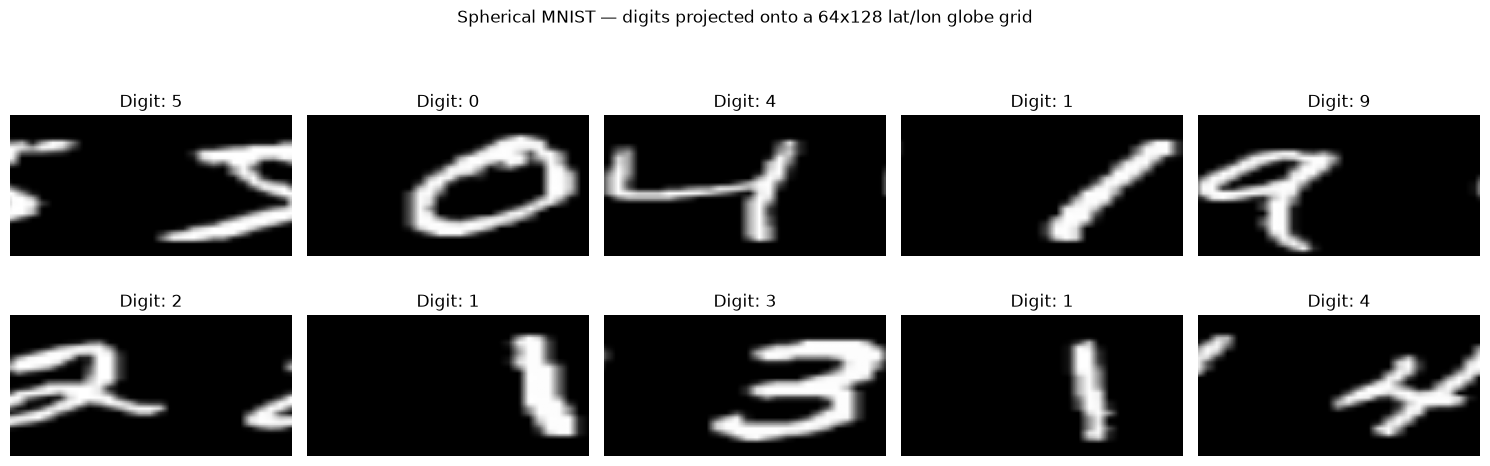

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, 0].numpy(), cmap='gray')
    ax.set_title(f'Digit: {y_train[i].item()}')
    ax.axis('off')
plt.suptitle('Spherical MNIST — digits projected onto a 64x128 lat/lon globe grid', y=1.02)
plt.tight_layout()
plt.show()
# Each image is a handwritten digit wrapped around a sphere (flattened back to 2D for viewing)
# Notice they look stretched — that's the spherical projection

## Cell 5 — Understand RealSHT shapes (run this, read the output)

Not building anything yet, printing shapes

In [13]:
sht  = RealSHT(NLAT, NLON, lmax=LMAX).to(device)
isht = InverseRealSHT(NLAT, NLON, lmax=LMAX).to(device)

# One batch of 4 spherical images, 1 channel
sample = X_train[:4].to(device)
print(f'Input (pixel space):       {sample.shape}')
# [batch, channels, nlat, nlon] = [4, 1, 64, 128]

coeffs = sht(sample)
print(f'After SHT (freq space):    {coeffs.shape}')
# [batch, channels, lmax, lmax+1] = [4, 1, 32, 33]
# These are the spherical harmonic coefficients

reconstructed = isht(coeffs)
print(f'After inverse SHT (pixel): {reconstructed.shape}')
# Back to [4, 1, 64, 128]

error = (sample - reconstructed).abs().mean().item()
print(f'Reconstruction error: {error:.6f}  (near 0 = transforms working correctly)')

Input (pixel space):       torch.Size([4, 1, 64, 128])
After SHT (freq space):    torch.Size([4, 1, 32, 65])
After inverse SHT (pixel): torch.Size([4, 1, 64, 128])
Reconstruction error: 0.015515  (near 0 = transforms working correctly)


## Cell 6 — Build SphericalConvLayer

The core building block. Does:
1. pixel → frequency (RealSHT)
2. multiply by learnable weights (the convolution)
3. frequency → pixel (InverseRealSHT)

In [14]:
class SphericalConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, nlat, nlon, lmax):
        super().__init__()
        self.sht  = RealSHT(nlat, nlon, lmax=lmax)
        self.isht = InverseRealSHT(nlat, nlon, lmax=lmax)
        # real and imaginary parts of filter weights separately
        self.weights_re = nn.Parameter(
            torch.randn(out_channels, in_channels, lmax, lmax) * 0.02
        )
        self.weights_im = nn.Parameter(
            torch.randn(out_channels, in_channels, lmax, lmax) * 0.02
        )

    def forward(self, x):
        # x: [batch, in_channels, nlat, nlon]
        x = self.sht(x)   # pixel → frequency (complex)

        # combine weights into complex tensor
        weights = torch.complex(self.weights_re, self.weights_im)

        # convolution in frequency space
        x = torch.einsum('bclm,oclm->bolm', x, weights)

        x = self.isht(x)  # frequency → pixel
        return x

# Shape test
layer = SphericalConvLayer(1, 16, NLAT, NLON, LMAX).to(device)
out   = layer(X_train[:4].to(device))
print(f'Layer input:  {X_train[:4].shape}')
print(f'Layer output: {out.shape}')

RuntimeError: einsum(): subscript m has size 32 for operand 1 which does not broadcast with previously seen size 65

## Cell 7 — Build the full Spherical CNN classifier

Stack spherical conv layers, then pool across the globe,
then a linear layer to classify into 10 digit classes.

In [ ]:
class SphericalMNISTModel(nn.Module):
    def __init__(self, nlat, nlon, lmax):
        super().__init__()
        self.conv1 = SphericalConvLayer(1,  16, nlat, nlon, lmax)
        self.conv2 = SphericalConvLayer(16, 32, nlat, nlon, lmax)
        self.conv3 = SphericalConvLayer(32, 16, nlat, nlon, lmax)
        # Pool across the globe → one vector per sample
        self.pool  = nn.AdaptiveAvgPool2d((4, 8))
        # Classify into 10 digit classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 4 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = self.classifier(x)
        return x  # [batch, 10] — one score per digit class


spherical_model = SphericalMNISTModel(NLAT, NLON, LMAX).to(device)
total_params = sum(p.numel() for p in spherical_model.parameters())
print(f'Spherical model parameters: {total_params:,}')

# Shape check
test_out = spherical_model(X_train[:4].to(device))
print(f'Output shape: {test_out.shape}')  # [4, 10] — 10 class scores per sample

Spherical model parameters: 2,196,874
Output shape: torch.Size([4, 10])


## Cell 8 — Build the flat CNN baseline

Same structure but uses regular CNN instead of SphericalConvLayer.
This is the comparison test.

In [ ]:
class FlatCNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        # Regular flat conv layers — no spherical transforms
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveAvgPool2d((4, 8))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 4 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = self.classifier(x)
        return x


flat_model = FlatCNNBaseline().to(device)
total_params_flat = sum(p.numel() for p in flat_model.parameters())
print(f'Flat model parameters: {total_params_flat:,}')

Flat model parameters: 76,378


## Cell 9 — Training loop (trains both models)

This will take a few minutes. Watch both loss values.
Spherical model should end up with higher accuracy than flat.

In [ ]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=15, lr=1e-3, name='Model'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=64, shuffle=True
    )

    train_losses, test_accs = [], []
    print(f'\n--- Training {name} ---')

    for epoch in range(epochs):
        # Train
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = loss_fn(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Evaluate
        model.eval()
        with torch.no_grad():
            test_pred = model(X_test.to(device))
            correct   = (test_pred.argmax(1) == y_test.to(device)).float().mean().item()

        train_losses.append(np.mean(batch_losses))
        test_accs.append(correct)
        print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {np.mean(batch_losses):.4f} | Test acc: {correct*100:.1f}%')

    return train_losses, test_accs


# Train spherical model
sph_losses, sph_accs = train_model(
    spherical_model, X_train, y_train, X_test, y_test,
    epochs=15, name='Spherical CNN'
)

# Train flat baseline
flat_losses, flat_accs = train_model(
    flat_model, X_train, y_train, X_test, y_test,
    epochs=15, name='Flat CNN Baseline'
)


--- Training Spherical CNN ---
Epoch  1/15 | Loss: 2.1401 | Test acc: 41.6%
Epoch  2/15 | Loss: 1.3657 | Test acc: 64.4%
Epoch  3/15 | Loss: 0.9879 | Test acc: 73.0%
Epoch  4/15 | Loss: 0.6967 | Test acc: 78.6%
Epoch  5/15 | Loss: 0.5356 | Test acc: 82.4%
Epoch  6/15 | Loss: 0.4449 | Test acc: 84.6%
Epoch  7/15 | Loss: 0.3632 | Test acc: 86.0%
Epoch  8/15 | Loss: 0.3079 | Test acc: 87.6%
Epoch  9/15 | Loss: 0.2804 | Test acc: 88.5%
Epoch 10/15 | Loss: 0.2337 | Test acc: 89.9%
Epoch 11/15 | Loss: 0.1958 | Test acc: 89.9%
Epoch 12/15 | Loss: 0.1794 | Test acc: 90.7%
Epoch 13/15 | Loss: 0.1466 | Test acc: 90.5%
Epoch 14/15 | Loss: 0.1280 | Test acc: 90.9%
Epoch 15/15 | Loss: 0.1014 | Test acc: 90.8%

--- Training Flat CNN Baseline ---
Epoch  1/15 | Loss: 1.9210 | Test acc: 49.7%
Epoch  2/15 | Loss: 1.2748 | Test acc: 61.4%
Epoch  3/15 | Loss: 1.0993 | Test acc: 66.6%
Epoch  4/15 | Loss: 0.9709 | Test acc: 68.5%
Epoch  5/15 | Loss: 0.9151 | Test acc: 72.8%
Epoch  6/15 | Loss: 0.8337 | Tes

## Cell 10 — Compare results

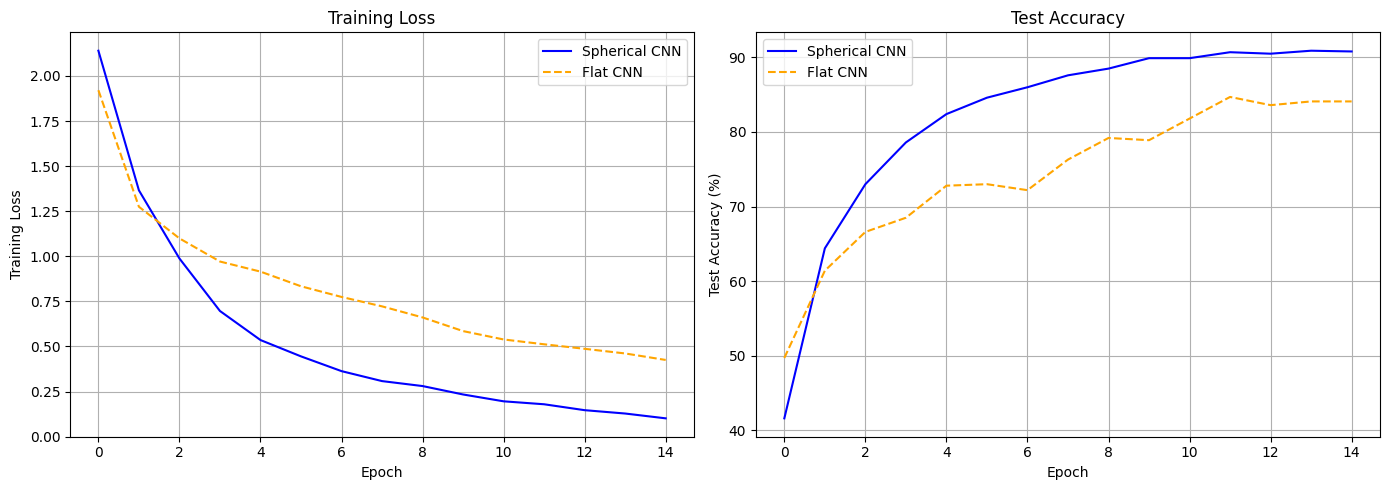


Final Results:
Spherical CNN accuracy: 90.8%
Flat CNN accuracy:      84.1%
Spherical advantage:    +6.7%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(sph_losses,  label='Spherical CNN', color='blue')
axes[0].plot(flat_losses, label='Flat CNN',       color='orange', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy curves
axes[1].plot([a*100 for a in sph_accs],  label='Spherical CNN', color='blue')
axes[1].plot([a*100 for a in flat_accs], label='Flat CNN',       color='orange', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'\nFinal Results:')
print(f'Spherical CNN accuracy: {sph_accs[-1]*100:.1f}%')
print(f'Flat CNN accuracy:      {flat_accs[-1]*100:.1f}%')
print(f'Spherical advantage:    {(sph_accs[-1] - flat_accs[-1])*100:+.1f}%')